# How to calculate the L2-norm of a field

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


fatal: not a git repository: '/opt/anaconda3/envs/felics/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 124 ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 132 ) : Mesh contains 513 nodes and 1024 elements
Info     | Reader.py              | _interpolate_to_calc_mesh  (line 706 ) : Linear interpolation took 0.6 seconds. (Mesh size: (1969, 2))


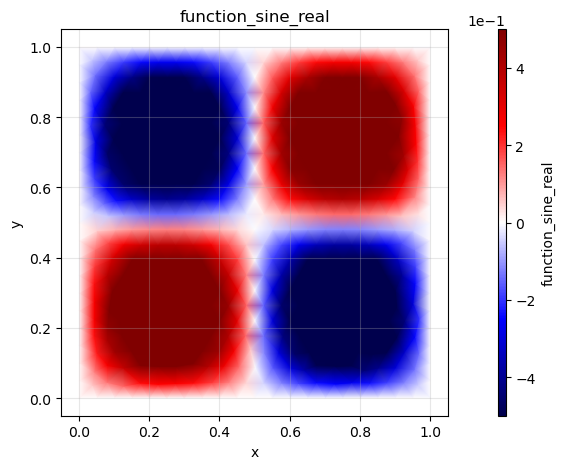

In [1]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import create_function_space
from FELiCS.Fields.Field         import Field
from FELiCS.IO.Reader            import Reader

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

scalarSpace = create_function_space(mesh, degree=2, dim=1)

phi = Field(scalarSpace, mesh=mesh, name="function_sine")
phi.import_data(Reader(),"input.h5")
phi.plot()


**Step 2: Calculate the L2-norm of a field**

Now we will calculate an integral quantity of our field. We will calculate the L2-norm of our field over the whole domain.

The L2-norm is defined as:

$$||\phi(\mathbf{x})||_{L^2} = \sqrt{\int_\Omega |\phi(\mathbf{x})|^2 \, d\Omega}$$

For this, the `Field` class has the method `calculateL2Norm()` which computes this integral over the entire mesh domain.


In [2]:
u_norm = phi.calculate_l2_norm()

print(f"L2-norm of the field: {u_norm}")

L2-norm of the field: (0.4995269134619802+0j)
